# Long-context retrieval: seven probes, small models locally and large models hosted

Two paths, because the measurements need different things.

**Local (T4).** Sink mass and the position-0 intervention need attention weights
and a custom mask, so they run on open checkpoints on the GPU. With a token,
gated models (Llama, Gemma) work here too.

**Hosted (your HF token).** The retrieval probes need only text out, so they run
on production-scale models through the Inference API. No T4 time, and this is
the only part that speaks to models of the size the paper declines to claim
anything about.

Seven probes, ordered by how much they defeat lexical matching:

| Probe | The task | Defeats |
| --- | --- | --- |
| `simple` | one fact, question repeats its wording | nothing: ceiling reference |
| `multikey` | 64 competing facts, same form | single-needle search |
| `nearkey` | competitors are near-duplicates (`room 12A` vs `12B`) | fuzzy key matching |
| `paraphrase` | six statement forms, reworded question | template matching |
| `twohop` | the code is reached through a second fact | direct lookup |
| `update` | the fact is stated, then revised later | recency-versus-retrieval |
| `count` | how many codes start with a digit | reading many items, not one |

Answers are scored whole (`4837-AX9`, several tokens), never on the first token.
Models that return non-finite logits in fp16 are reloaded in fp32, which is what
produced `nan` in v1.

In [1]:
!pip -q install -U "transformers>=4.44" accelerate huggingface_hub

import gc, json, math, random, re, time
import torch

try:                                  # Colab secret named HF_TOKEN, else paste one
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    import getpass
    HF_TOKEN = getpass.getpass("HF token (leave blank to skip gated and hosted models): ").strip() or None

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("token loaded")

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"{p.name}, {p.total_memory / 1e9:.1f} GB")
    torch.backends.cuda.matmul.allow_tf32 = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 24.4 MB/s eta 0:00:00
token loaded
torch 2.11.0+cu128 | cuda: True
Tesla T4, 15.6 GB


In [2]:
# --- local models: internals available, so sink mass and the intervention work
LOCAL_MODELS = [
    "HuggingFaceTB/SmolLM2-360M",
    "Qwen/Qwen2.5-0.5B",
    "Qwen/Qwen3-0.6B-Base",
    "Qwen/Qwen2.5-1.5B",
    "Qwen/Qwen3-1.7B-Base",
]
if HF_TOKEN:                          # gated, and worth having: different families
    LOCAL_MODELS += ["meta-llama/Llama-3.2-1B", "google/gemma-2-2b"]

# --- hosted models: text only, no GPU here. Skipped when RUN_HOSTED is False.
RUN_HOSTED = True
HOSTED_MODELS = [
    "meta-llama/Llama-3.3-70B-Instruct",
    "Qwen/Qwen2.5-72B-Instruct",
    "deepseek-ai/DeepSeek-V3-0324",
]

PROBES       = ["simple", "multikey", "nearkey", "paraphrase", "twohop", "update", "count"]
LENGTHS      = [1024, 4096, 8192]     # local; capped per model
DEPTHS       = [round(0.02 + i * 0.96 / 11, 3) for i in range(12)]
PROMPTS      = 2
DISTRACTORS  = 64
SINK_LENGTH  = 1024
HARD_LENGTH  = 4096                   # where the ladder and the intervention run
SEED         = 0

# Hosted budget. Each call sends the whole context, so this is the cost knob.
HOSTED_LENGTH  = 8192
HOSTED_DEPTHS  = [0.05, 0.25, 0.5, 0.75, 0.95]
HOSTED_PROBES  = ["multikey", "paraphrase", "twohop", "update"]
print(f"hosted plan: {len(HOSTED_MODELS)} models x {len(HOSTED_PROBES)} probes x "
      f"{len(HOSTED_DEPTHS)} depths = {len(HOSTED_MODELS) * len(HOSTED_PROBES) * len(HOSTED_DEPTHS)} calls, "
      f"about {len(HOSTED_MODELS) * len(HOSTED_PROBES) * len(HOSTED_DEPTHS) * HOSTED_LENGTH / 1e6:.2f}M input tokens")

hosted plan: 3 models x 4 probes x 5 depths = 60 calls, about 0.49M input tokens


In [3]:
FILLER = [
    "The committee met on Tuesday to review the quarterly figures.",
    "Rainfall in the northern districts stayed below the seasonal average.",
    "A new footbridge opened near the old railway yard last spring.",
    "The library extended its opening hours during the examination period.",
    "Several varieties of wheat were planted in the eastern fields.",
    "The museum acquired a collection of maps from a private donor.",
    "Traffic on the coastal road was diverted for three weeks.",
    "Researchers presented their findings at the annual meeting.",
    "The cafe on the corner changed owners in the autumn.",
    "Snow closed the mountain pass earlier than usual this year.",
    "The ferry timetable changes at the end of the month.",
    "A local choir rehearses in the hall on Thursday evenings.",
]
WINGS  = [f"the {d} {n}" for d in ("west", "north", "east", "south")
          for n in ("wing", "annexe", "gallery", "stairwell", "workshop", "store")]
ROOMS  = [f"room {n}{c}" for n in range(10, 40) for c in "ABCD"]
PLACES = WINGS + ROOMS

FORMS = [
    "The access code for {k} is {v}.",
    "{k} uses credential {v}.",
    "Entry to {k} requires the sequence {v}.",
    "Security identifier for {k}: {v}.",
    "Staff enter {v} to unlock {k}.",
    "{k} was reassigned the code {v} last quarter.",
]
ASK_PLAIN  = "\n\nQuestion: What is the access code for {k}?\nAnswer: The access code for {k} is"
ASK_PARA   = "\n\nQuestion: Which credential should be entered to open {k}?\nAnswer:"
ASK_LATEST = "\n\nQuestion: What is the current access code for {k}, after any change?\nAnswer:"
ASK_COUNT  = "\n\nQuestion: How many access codes in the text above begin with the digit {d}?\nAnswer:"


def make_code(rng, first=None):
    head = str(rng.randint(1000, 9999)) if first is None else str(first) + str(rng.randint(100, 999))
    letters = "".join(rng.choice("ABCDEFGHJKLMNPQRSTVWXYZ") for _ in range(2))
    return f"{head}-{letters}{rng.randint(0, 9)}"


def build_case(tok, probe, target_tokens, depth, rng, _lens={}):
    """Return (prompt, gold). Assembled from whole sentences, tokenized once."""
    if probe == "nearkey":                      # competitors differ by one character
        stem = rng.randint(10, 39)
        names = [f"room {stem}{c}" for c in "ABCD"] + rng.sample(ROOMS, DISTRACTORS)
    else:
        names = rng.sample(PLACES, DISTRACTORS + 3)
    target, code = names[0], make_code(rng)
    plain = probe in ("simple", "multikey", "nearkey")
    form = (lambda: FORMS[0] if plain else rng.choice(FORMS))

    facts, ask, gold, revision = [], ASK_PLAIN.format(k=target), " " + code, None
    if probe == "twohop":
        other = names[1]
        facts = [FORMS[0].format(k=other, v=code),
                 f"{target} shares the same access code as {other}."]
    elif probe == "update":
        facts = [form().format(k=target, v=make_code(rng))]      # the stale value
        revision = f"The access code for {target} was changed to {code}."
        ask = ASK_LATEST.format(k=target)
    elif probe != "count":
        facts = [form().format(k=target, v=code)]
        ask = (ASK_PLAIN if plain else ASK_PARA).format(k=target)

    competitors, digit_hits = [], 0
    if probe != "simple":
        digit = rng.choice("2345678")
        for i, other in enumerate(names[2:]):
            if probe == "count":
                use = (i % 5 == 0)
                c = make_code(rng, first=digit if use else rng.choice("19"))
                digit_hits += use
            else:
                c = make_code(rng)
            competitors.append(form().format(k=other, v=c))
        if probe == "count":
            ask, gold = ASK_COUNT.format(d=digit), " " + str(digit_hits)

    # Sentence lengths, measured once per tokenizer, so the context lands near
    # target_tokens without tokenizing and decoding the whole passage twice.
    key = id(tok)
    if key not in _lens:
        _lens[key] = (sum(len(tok(s + " ", add_special_tokens=False).input_ids) for s in FILLER) / len(FILLER),
                      len(tok(FORMS[0].format(k="room 12A", v="1234-AB5") + " ",
                              add_special_tokens=False).input_ids))
    filler_len, fact_len = _lens[key]
    budget = target_tokens - fact_len * (len(competitors) + len(facts) + (1 if revision else 0))
    body = [rng.choice(FILLER) for _ in range(max(8, int(budget / filler_len)))]
    for text in competitors:
        body.insert(rng.randrange(len(body) + 1), text)

    at = min(len(body), max(1, int(len(body) * depth)))
    for j, fact in enumerate(facts):
        body.insert(at + j, fact)
    if revision:                                # the revision lands after the stale value
        body.insert(min(len(body), at + len(facts) + max(3, (len(body) - at) // 2)), revision)
    return " ".join(body) + ask, gold

In [4]:
def uniform_sink_reference(T):
    t = torch.arange(1, T, dtype=torch.float64)
    return float((1.0 / (t + 1.0)).mean())


@torch.no_grad()
def sink_mass(model, ids):
    out = model(ids, output_attentions=True, use_cache=False)
    vals = [a[0, :, 1:, 0].float().mean().item() for a in out.attentions]
    del out
    torch.cuda.empty_cache()
    vals = [v for v in vals if math.isfinite(v)]
    return sum(vals) / len(vals) if vals else float("nan")


def no_sink_mask(T, dtype, device):
    neg = torch.finfo(dtype).min
    m = torch.triu(torch.full((T, T), neg, dtype=dtype, device=device), diagonal=1)
    m[1:, 0] = neg
    return m[None, None]


@torch.no_grad()
def score_teacher_forced(model, tok, prompt, gold, remove_sink=False):
    """Every gold token must be the argmax given the gold prefix."""
    p = tok(prompt, return_tensors="pt").input_ids
    a = tok(gold, add_special_tokens=False, return_tensors="pt").input_ids
    ids = torch.cat([p, a], dim=1).to(model.device)
    kwargs = {"use_cache": False}
    if remove_sink:
        kwargs["attention_mask"] = no_sink_mask(ids.shape[1], model.dtype, ids.device)
    logits = model(ids, **kwargs).logits[0]
    n = a.shape[1]
    pred = logits[-n - 1:-1].argmax(-1).cpu()
    emitted = bool(re.match(r"^[0-9A-Z]", tok.decode(pred[:1]).strip()))
    return bool((pred == a[0]).all()), emitted


@torch.no_grad()
def score_generated(model, tok, prompt, gold, max_new_tokens=12):
    """Free generation, so local numbers are comparable with the hosted ones."""
    ids = tok(prompt, return_tensors="pt").input_ids.to(model.device)
    out = model.generate(ids, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tok.eos_token_id)
    text = tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True)
    return gold.strip() in text, text.strip()[:24]

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer


def load(name):
    tok = AutoTokenizer.from_pretrained(name, token=HF_TOKEN)
    for dtype in (torch.float16, torch.float32):
        model = AutoModelForCausalLM.from_pretrained(
            name, torch_dtype=dtype, token=HF_TOKEN).cuda().eval()
        with torch.no_grad():
            ids = tok("The access code for the west wing is", return_tensors="pt").input_ids.cuda()
            if torch.isfinite(model(ids).logits).all().item():
                return tok, model, str(dtype).split(".")[-1]
        print(f"  non-finite logits in {dtype}, reloading in float32", flush=True)
        del model
        gc.collect(); torch.cuda.empty_cache()
    raise RuntimeError("non-finite logits even in float32")


def run_local_probe(model, tok, probe, length, rng, remove_sink=False, generate=False):
    exact = emitted = gen_hits = 0
    by_depth = []
    for d in DEPTHS:
        hits = 0
        for _ in range(PROMPTS):
            prompt, gold = build_case(tok, probe, length, d, rng)
            ok, emit = score_teacher_forced(model, tok, prompt, gold, remove_sink)
            hits += ok; exact += ok; emitted += emit
            if generate:
                g, _ = score_generated(model, tok, prompt, gold)
                gen_hits += g
        by_depth.append(hits / PROMPTS)
    n = len(DEPTHS) * PROMPTS
    out = {"exact": exact / n, "emitted_code": emitted / n, "profile": by_depth}
    if generate:
        out["generated"] = gen_hits / n
    return out


def probe_local(name):
    started = time.time()
    tok, model, dtype = load(name)
    limit = getattr(model.config, "max_position_embeddings", 8192) or 8192
    rng = random.Random(SEED)
    row = {"model": name, "where": "local", "dtype": dtype, "max_positions": limit,
           "params_b": sum(p.numel() for p in model.parameters()) / 1e9, "probes": {}}

    ids = tok(" ".join(rng.choice(FILLER) for _ in range(SINK_LENGTH)),
              return_tensors="pt").input_ids[:, :SINK_LENGTH].cuda()
    mass = sink_mass(model, ids)
    row["sink_mass"], row["sink_ratio"] = mass, mass / uniform_sink_reference(ids.shape[1])
    print(f"{name} [{dtype}]: sink {mass:.3f}, {row['sink_ratio']:.1f}x uniform", flush=True)

    lengths = [L for L in LENGTHS if L <= limit - 256]
    for probe in PROBES:
        use = lengths if probe in ("multikey", "paraphrase") else \
              ([HARD_LENGTH] if HARD_LENGTH in lengths else lengths[:1])
        for L in use:
            res = run_local_probe(model, tok, probe, L, random.Random(SEED + L),
                                  generate=(probe == "paraphrase" and L == HARD_LENGTH))
            row["probes"][f"{probe}@{L}"] = res
            extra = f"  generated {100 * res['generated']:5.1f}%" if "generated" in res else ""
            print(f"  {probe:11s} {L:5d}: exact {100 * res['exact']:5.1f}%  "
                  f"emitted a code {100 * res['emitted_code']:5.1f}%{extra}", flush=True)

    key = f"paraphrase@{HARD_LENGTH}"
    if key in row["probes"]:
        off = run_local_probe(model, tok, "paraphrase", HARD_LENGTH,
                              random.Random(SEED + HARD_LENGTH), remove_sink=True)
        row["intervention"] = {"length": HARD_LENGTH, "kept": row["probes"][key]["exact"],
                               "removed": off["exact"]}
        print(f"  position 0 removed: {100 * row['probes'][key]['exact']:.1f}% -> "
              f"{100 * off['exact']:.1f}% on the hard probe", flush=True)

    del model, tok
    gc.collect(); torch.cuda.empty_cache()
    row["seconds"] = round(time.time() - started, 1)
    return row

In [6]:
results = []
for name in LOCAL_MODELS:
    try:
        results.append(probe_local(name))
    except Exception as exc:
        print(f"{name}: skipped ({type(exc).__name__}: {exc})", flush=True)
        gc.collect(); torch.cuda.empty_cache()
json.dump(results, open("probe_local.json", "w"), indent=1)
print(f"\n{len(results)} local models, written to probe_local.json")

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Qwen/Qwen3-1.7B-Base [float16]: sink nan, nanx uniform
  simple       4096: exact 100.0%  emitted a code   0.0%
  multikey     1024: exact 100.0%  emitted a code   0.0%
  multikey     4096: exact  95.8%  emitted a code   0.0%
  multikey     8192: exact  91.7%  emitted a code   0.0%
  nearkey      4096: exact  62.5%  emitted a code   0.0%
  paraphrase   1024: exact  87.5%  emitted a code   4.2%
  paraphrase   4096: exact  79.2%  emitted a code   0.0%  generated  79.2%
  paraphrase   8192: exact  87.5%  emitted a code   0.0%
  twohop       4096: exact   8.3%  emitted a code   0.0%
  update       4096: exact  95.8%  emitted a code   0.0%
  count        4096: exact   0.0%  emitted a code   0.0%
  position 0 removed: 79.2% -> 79.2% on the hard probe
meta-llama/Llama-3.2-1B: skipped (OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.2-1B.
403 Client Error. (Request ID: Root=1-6aaa4a73-3a3b22c31bc90d6d27403822;da03f4ee-

In [10]:
# Hosted models: text in, text out. No attention internals, so no sink or
# intervention here, but these are the sizes the paper will not claim anything about.
from huggingface_hub import InferenceClient
from transformers import AutoTokenizer

hosted = []
if RUN_HOSTED and HF_TOKEN:
    builder_tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")   # only to lay out prompts
    client = InferenceClient(token=HF_TOKEN)
    for name in HOSTED_MODELS:
        row = {"model": name, "where": "hosted", "probes": {}}
        try:
            for probe in HOSTED_PROBES:
                hits, n, by_depth = 0, 0, []
                for d in HOSTED_DEPTHS:
                    prompt, gold = build_case(builder_tok, probe, HOSTED_LENGTH, d,
                                              random.Random(SEED + int(d * 1000)))
                    reply = client.chat_completion(
                        model=name, max_tokens=16, temperature=0,
                        messages=[{"role": "user", "content": prompt +
                                   "\n\nReply with the answer only."}]
                    ).choices[0].message.content
                    ok = gold.strip() in (reply or "")
                    by_depth.append(float(ok)); hits += ok; n += 1
                row["probes"][f"{probe}@{HOSTED_LENGTH}"] = {"exact": hits / n, "profile": by_depth}
                print(f"{name}: {probe:11s} {100 * hits / n:5.1f}%  by depth "
                      + " ".join(f"{int(100 * v):3d}" for v in by_depth), flush=True)
            hosted.append(row)
        except Exception as exc:
            print(f"{name}: skipped ({type(exc).__name__}: {exc})", flush=True)
    json.dump(hosted, open("probe_hosted.json", "w"), indent=1)
else:
    print("hosted probes skipped (set RUN_HOSTED and provide a token to enable)")

meta-llama/Llama-3.3-70B-Instruct: skipped (HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6aaa4ce3-0bc90569046b155c15792614;214a2b0d-1a46-48e6-91fb-3fd37b11b2b7)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.)
Qwen/Qwen2.5-72B-Instruct: skipped (HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6aaa4ce3-775298a972d18c5119b8236b;5196b12b-7297-4eb3-9495-0e2442236293)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 

In [8]:
def cell(r, key):
    p = r["probes"].get(key)
    return f"{100 * p['exact']:5.1f}" if p else "    --"

cols = [("simple", HARD_LENGTH), ("multikey", HARD_LENGTH), ("nearkey", HARD_LENGTH),
        ("paraphrase", HARD_LENGTH), ("twohop", HARD_LENGTH), ("update", HARD_LENGTH),
        ("count", HARD_LENGTH)]
head = f"{'model':26s} {'dtype':>7s} {'sink':>6s} {'xunif':>6s} " + \
       " ".join(f"{p[:6]:>6s}" for p, _ in cols) + f" {'sink off':>9s}"
print(head); print("-" * len(head))
for r in results:
    iv = r.get("intervention")
    delta = f"{100 * (iv['removed'] - iv['kept']):+8.1f}" if iv else "       --"
    print(f"{r['model'].split('/')[-1][:26]:26s} {r['dtype']:>7s} {r['sink_mass']:6.3f} "
          f"{r['sink_ratio']:6.1f} " + " ".join(cell(r, f"{p}@{L}") for p, L in cols) + f" {delta}")

if hosted:
    print()
    head = f"{'hosted model':34s} " + " ".join(f"{p[:9]:>9s}" for p in HOSTED_PROBES)
    print(head); print("-" * len(head))
    for r in hosted:
        print(f"{r['model'][:34]:34s} " +
              " ".join(cell(r, f"{p}@{HOSTED_LENGTH}").rjust(9) for p in HOSTED_PROBES))

model                        dtype   sink  xunif simple multik nearke paraph twohop update  count  sink off
-----------------------------------------------------------------------------------------------------------
SmolLM2-360M               float16    nan    nan 100.0  20.8  20.8  12.5  33.3  16.7   0.0     -4.2
Qwen2.5-0.5B               float16    nan    nan 100.0  70.8  70.8   0.0   8.3   0.0   0.0     +0.0
Qwen3-0.6B-Base            float16    nan    nan 100.0  91.7  50.0  66.7  29.2  95.8   0.0     -4.2
Qwen2.5-1.5B               float16    nan    nan 100.0  95.8  66.7  45.8  33.3  45.8   0.0     +0.0
Qwen3-1.7B-Base            float16    nan    nan 100.0  95.8  62.5  79.2   8.3  95.8   0.0     +0.0


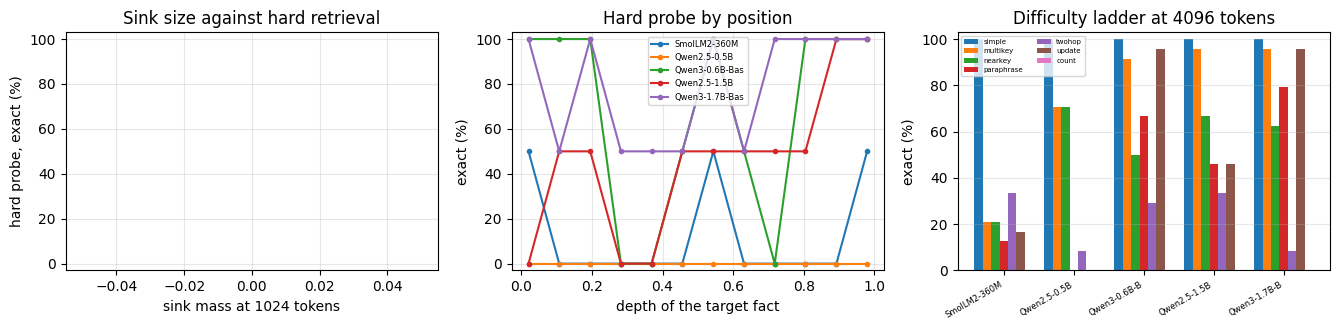

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.4))

for r in results:
    p = r["probes"].get(f"paraphrase@{HARD_LENGTH}")
    if p:
        ax[0].scatter(r["sink_mass"], 100 * p["exact"], s=48, zorder=3)
        ax[0].annotate(r["model"].split("/")[-1][:14], (r["sink_mass"], 100 * p["exact"]),
                       xytext=(4, 4), textcoords="offset points", fontsize=7)
ax[0].set_xlabel("sink mass at 1024 tokens"); ax[0].set_ylabel("hard probe, exact (%)")
ax[0].set_title("Sink size against hard retrieval"); ax[0].set_ylim(-3, 103); ax[0].grid(alpha=0.3)

for r in results:
    p = r["probes"].get(f"paraphrase@{HARD_LENGTH}")
    if p:
        ax[1].plot(DEPTHS, [100 * v for v in p["profile"]], marker="o", ms=3,
                   label=r["model"].split("/")[-1][:14])
for r in hosted:
    p = r["probes"].get(f"paraphrase@{HOSTED_LENGTH}")
    if p:
        ax[1].plot(HOSTED_DEPTHS, [100 * v for v in p["profile"]], marker="s", ms=4, ls="--",
                   label=r["model"].split("/")[-1][:14] + " (hosted)")
ax[1].set_xlabel("depth of the target fact"); ax[1].set_ylabel("exact (%)")
ax[1].set_title("Hard probe by position"); ax[1].set_ylim(-3, 103)
ax[1].grid(alpha=0.3); ax[1].legend(fontsize=6)

names = [r["model"].split("/")[-1][:12] for r in results]
for i, (probe, L) in enumerate(cols):
    vals = [100 * r["probes"][f"{probe}@{L}"]["exact"] if f"{probe}@{L}" in r["probes"] else 0
            for r in results]
    ax[2].bar([x + i * 0.12 for x in range(len(results))], vals, 0.12, label=probe)
ax[2].set_xticks([x + 0.36 for x in range(len(results))])
ax[2].set_xticklabels(names, rotation=30, ha="right", fontsize=6)
ax[2].set_ylabel("exact (%)"); ax[2].set_title(f"Difficulty ladder at {HARD_LENGTH} tokens")
ax[2].set_ylim(0, 103); ax[2].grid(alpha=0.3, axis="y"); ax[2].legend(fontsize=5, ncol=2)

plt.tight_layout(); plt.show()

## Reading the output

- **Read the ladder, not any single cell.** `simple` should saturate; it is v1.
  The question is where `nearkey`, `paraphrase`, `twohop`, `update` and `count`
  fall. If everything still saturates, the probe is still too easy and that is
  the finding, not a claim about the models.
- **`sink off`** is the intervention, run on a probe with headroom rather than
  against a ceiling. Near zero means retrieval does not run through position 0.
- **`emitted a code`** separates readout from retrieval: prose instead of a code
  scores zero without any retrieval failure. The controlled study hit the same
  confusion with marker tokens, so it is worth watching.
- **`dtype`** flags any model that needed float32. That is an fp16 overflow in
  the checkpoint, not a statement about long context.
- **Hosted rows** carry no sink or intervention, by construction. They exist to
  answer one question: do the retrieval failures the small local models show
  survive at production scale?

Cost. Each hosted call sends the whole context, so the plan printed in the
config cell is the bill. Trim `HOSTED_DEPTHS` or `HOSTED_MODELS` before running
if that matters, and raise `PROMPTS` only for the local path, which is free.

Scope. This tests whether the diagnostics transfer to released weights. It
cannot test the paper's mechanism claim, which is about training dynamics and
needs training runs.